# Contour Identification & Coloring — from scratch



In [1]:
 
import os
import glob
 
import numpy as np
import cv2  # used ONLY to decode PNG files into arrays
 
from contour_utils import (
    label_contours,
    remove_small_contours,
    remove_edge_contours,
    colorize
)
 
# ===========================================================================
# Configuration
# ===========================================================================
DATA_DIR     = "./tile/L1000917"   # folder containing tile_*.png
FG_THRESHOLD = 50                  # intensity above which a pixel is "contour"
MIN_PIXELS   = 100                 # drop contours smaller than this (pixel count)
EDGE_MARGIN  = 2                   # drop contours with a pixel < this many px from an edge
 
SHOW_RESULTS     = True            # <-- toggle the result viewing panel on / off
MAX_VIEW_SAMPLES = 20              # viewing panel renders at most this many tiles
 
 
# ===========================================================================
# Dataset loading
# ===========================================================================
def load_dataset(data_dir: str = DATA_DIR) -> dict[str, np.ndarray]:
    """Load every ``tile_*.png`` in `data_dir` as a grayscale array.
 
    Returns an ordered ``{filename: image}`` dict.
    """
    paths = sorted(glob.glob(os.path.join(data_dir, "tile_*.png")))
    if not paths:
        raise FileNotFoundError(f"No tile_*.png found in {data_dir!r}")
    return {os.path.basename(p): cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in paths}
 
 
# ===========================================================================
# Noise-removal pipeline
# ===========================================================================
def remove_noise_contours(image: np.ndarray,
                          fg_threshold: int = FG_THRESHOLD,
                          min_pixels: int = MIN_PIXELS,
                          edge_margin: int = EDGE_MARGIN) -> np.ndarray:
    """Remove noise contours from a single grayscale tile.
 
    Pipeline: threshold -> connected-component labeling -> drop small
    contours -> drop frame-touching contours.
 
    Parameters
    ----------
    image : np.ndarray
        2D grayscale tile.
    fg_threshold, min_pixels, edge_margin : int
        Pipeline parameters (default to the module-level constants).
 
    Returns
    -------
    np.ndarray
        int label map of the surviving contours -- 0 = background,
        1..N = cleaned contours, renumbered contiguously.
    """
    mask   = image > fg_threshold
    labels = label_contours(mask)
    labels = remove_small_contours(labels, min_pixels)
    labels = remove_edge_contours(labels, edge_margin)
    return labels
 
 
def process_dataset(tiles: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Apply :func:`remove_noise_contours` to every tile in the dataset.
 
    Returns ``{filename: cleaned label map}``.
    """
    return {name: remove_noise_contours(img) for name, img in tiles.items()}
 
 
# ===========================================================================
# Result viewing panel  (optional -- controlled by SHOW_RESULTS)
# ===========================================================================
def show_results(tiles: dict[str, np.ndarray],
                 max_samples: int = MAX_VIEW_SAMPLES) -> None:
    """Display a 4-stage before/after comparison, one row per tile.
 
    Columns: input image | contours coloured | post small-contour dropout |
    post frame-touching dropout. Renders at most `max_samples` tiles.
    """
    import matplotlib.pyplot as plt  # lazy import: core pipeline stays headless
 
    sample = dict(list(tiles.items())[:max_samples])
    stage_titles = [
        "input image",
        "contours identified & coloured",
        f"post small-contour dropout (min size = {MIN_PIXELS} px)",
        f"post frame-touching dropout (margin = {EDGE_MARGIN} px)",
    ]
 
    n = len(sample)
    fig, axes = plt.subplots(n, 4, figsize=(15, 3.4 * n))
    axes = np.atleast_2d(axes)
 
    for row, (name, img) in enumerate(sample.items()):
        raw   = label_contours(img > FG_THRESHOLD)        # stage 2
        small = remove_small_contours(raw, MIN_PIXELS)    # stage 3
        edge  = remove_edge_contours(small, EDGE_MARGIN)  # stage 4
        panels = [(img, None), (raw, raw.max()),
                  (small, small.max()), (edge, edge.max())]
 
        for col, (data, count) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(data, cmap="gray") if col == 0 else ax.imshow(colorize(data))
            if row == 0:
                ax.set_title(stage_titles[col], fontsize=9)
            if count is not None:
                ax.text(0.5, -0.07, f"{count} contour(s)", fontsize=8,
                        ha="center", va="top", transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
        axes[row, 0].set_ylabel(name, fontsize=8)
 
    plt.tight_layout()
    plt.show()
 
 


Loaded 301 tile(s) from ./tile/L1000917
Processed 301 tile(s); 42 contour(s) survived noise removal.


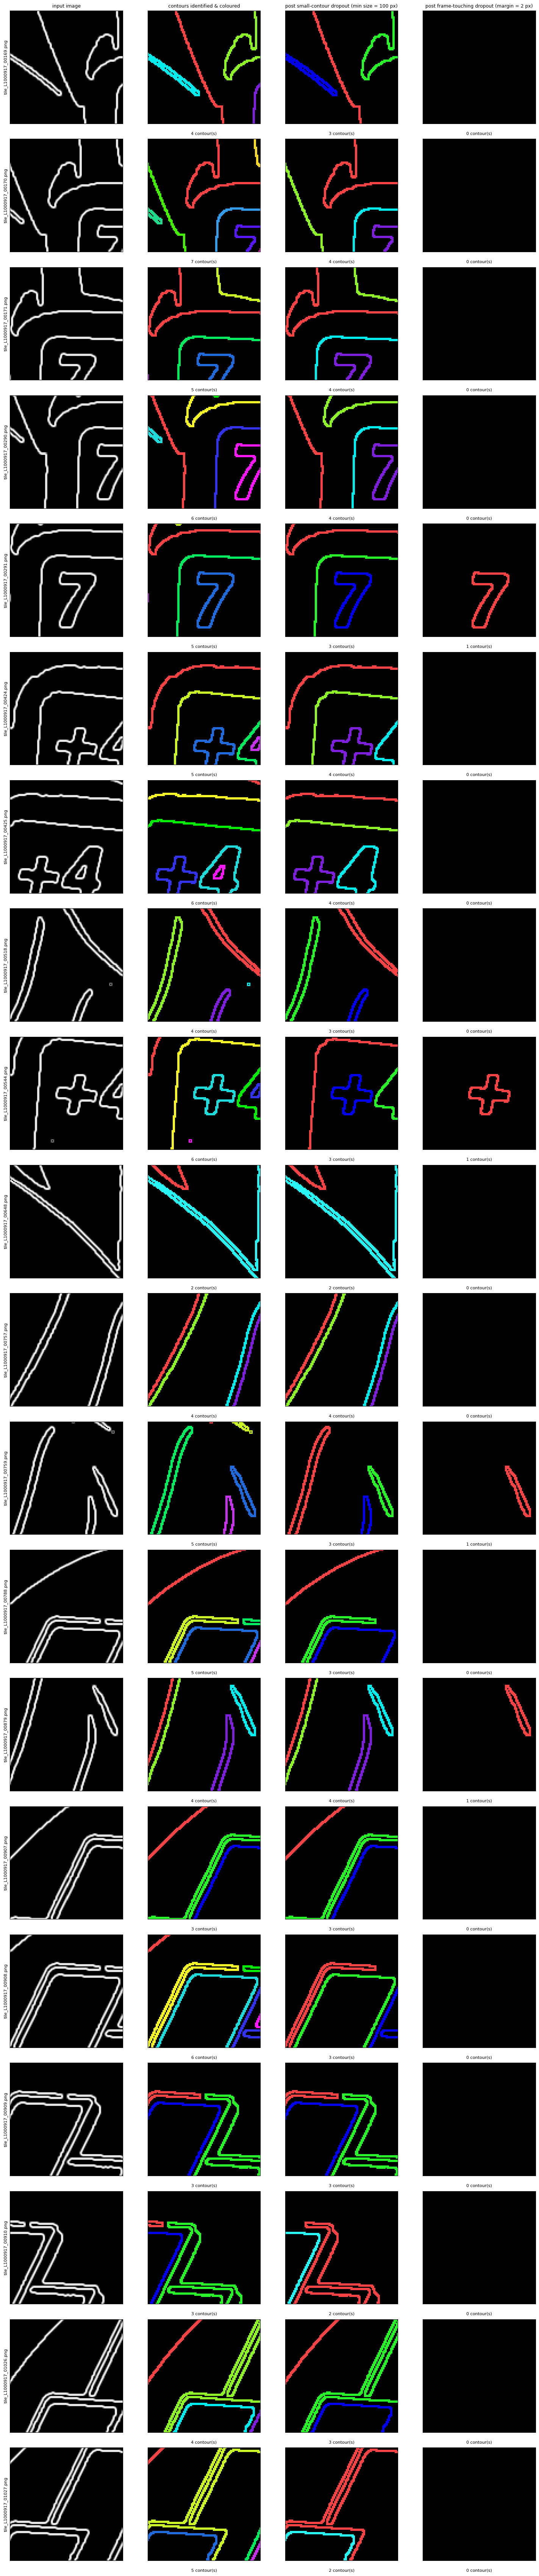

In [2]:
# to be encapsulated into a single remove_noise_contours function.
tiles = load_dataset()
print(f"Loaded {len(tiles)} tile(s) from {DATA_DIR}")

cleaned = process_dataset(tiles)            # <-- function call on the dataset
total = sum(int(lbl.max()) for lbl in cleaned.values())
print(f"Processed {len(cleaned)} tile(s); "
        f"{total} contour(s) survived noise removal.")

if SHOW_RESULTS:
    show_results(tiles)
 